<a href="https://colab.research.google.com/github/guilhermevalverdefreiria/IC_FAPESP_2025/blob/main/C%C3%B3digoICFapesp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

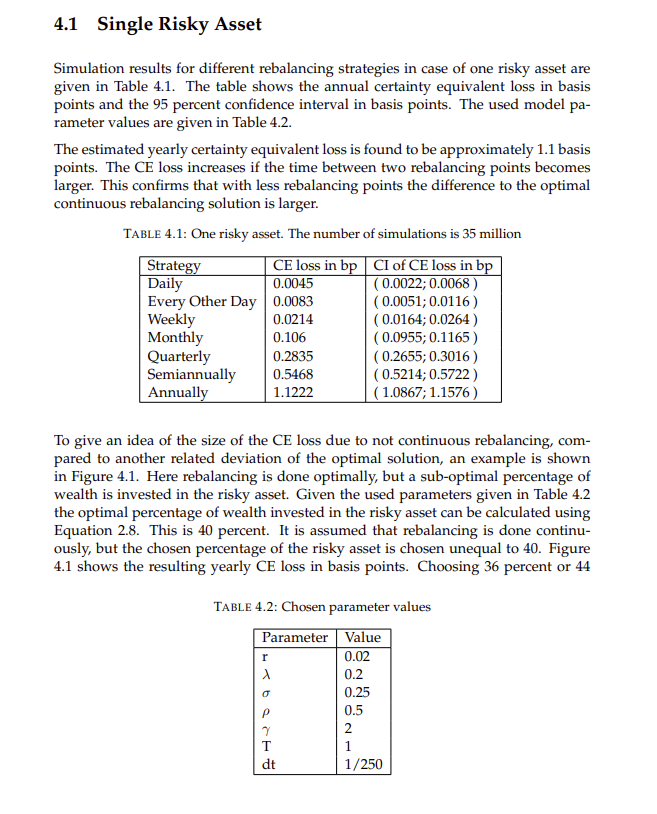

In [ ]:
# =========================
# Simulação de GBM
# =========================
simular_gbm <- function(r, lam, sigma, dt, S0, dB) {
  N <- nrow(dB)
  n_steps <- ncol(dB)

  drift <- (r + lam * sigma - 0.5 * sigma^2) * dt

  S <- matrix(0, nrow = N, ncol = n_steps + 1)
  S[, 1] <- S0

  for (j in 1:n_steps) {
    S[, j + 1] <- S[, j] * exp(drift + sigma * dB[, j])
  }

  return(S)
}

# =========================
# Simulação de riqueza discreta
# =========================
simular_riqueza_discreta <- function(S, r, lam, sigma, gamma, dt, W0, rebalance_freq) {
  N <- nrow(S)
  n_points <- ncol(S)
  n_steps <- n_points - 1

  W <- matrix(0, nrow = N, ncol = n_points)
  W[, 1] <- W0

  w_star <- lam / (gamma * sigma)
  risk_free_factor <- exp(r * dt)

  phi <- (w_star * W0) / S[, 1] #Não há necessidade de ser inteiro, posso comprar fracoes das acoes
  psi <- rep((1 - w_star) * W0, N)

  # CORREÇÃO: Verifica se rebalance_freq é válido
  if (rebalance_freq <= n_steps) {
    rebalance_points <- seq(rebalance_freq, n_points, by = rebalance_freq)
  } else {
    rebalance_points <- integer(0)  # Nunca rebalanceia
  }

  for (j in 1:n_steps) {
    psi <- psi * risk_free_factor
    S_next <- S[, j + 1]
    W_i <- phi * S_next + psi
    W[, j + 1] <- W_i

    if ((j + 1) %in% rebalance_points) {
      phi <- (w_star * W_i) / S_next
      psi <- (1 - w_star) * W_i
    }
  }

  return(W)
}

# =========================
# Tabela de perdas (COM PROGRESSO E CORREÇÕES)
# =========================
tabela_ce_loss1 <- function(r, lam, sigma, gamma, T, W0,
                            N = 1000, S0 = 1, seed = NULL,
                            show_progress = TRUE) {

  if (!is.null(seed)) set.seed(seed)

  dt <- 1/250
  n_steps <- as.integer(T / dt)
  n_points <- n_steps + 1

  if (show_progress) {
    message(sprintf("Configuração: N=%d, steps=%d, dt=%.4f", N, n_steps, dt))
  }

  # Gera dB
  dB <- matrix(rnorm(N * n_steps, sd = sqrt(dt)),
               nrow = N, ncol = n_steps)

  if (show_progress) {
    message(sprintf("dB alocado: %.2f GB", object.size(dB) / 1e9))
  }

  # Simula GBM
  if (show_progress) message("Simulando GBM...")
  S <- simular_gbm(r, lam, sigma, dt, S0, dB)

  rm(dB) #Remove da memoria
  gc() #Limpa a memória

  # Cálculo teórico
  w_star <- lam / (gamma * sigma)
  mu_P <- r + lam * sigma * w_star
  sigma_P <- sigma
  EU_theoretical <- expected_utility_raw(W0, mu_P, sigma_P, w_star, gamma, T)
  CE_theoretical <- ce_from_expected_utility(EU_theoretical, gamma)

  if (show_progress) {
    message(sprintf("CE Teórico: %.6f", CE_theoretical))
  }

  # Estratégias
  estrategias <- c(
    "Daily" = 1,
    "Every Other Day" = 2,
    "Weekly" = 5,
    "Monthly" = 21,
    "Quarterly" = 63,
    "Semiannually" = 125,
    "Annually" = 250
  )

  # Filtra estratégias válidas (opcional: mantém todas)
  # estrategias_validas <- estrategias[estrategias <= n_steps]

  # Cria um vetor numérico de zeros com o mesmo tamanho do número de estratégias
  # Esse vetor vai armazenar as perdas (CE loss) de cada estratégia
  losses <- numeric(length(estrategias))

  # Atribui nomes ao vetor 'losses' iguais aos nomes das estratégias
  # Isso permite acessar os resultados por nome (ex: losses["Monthly"])
  names(losses) <- names(estrategias)

  # Cria outro vetor numérico de zeros para armazenar o Certainty Equivalent (CE)
  # Também com o mesmo tamanho do número de estratégias
  ces <- numeric(length(estrategias))

  # Atribui os mesmos nomes das estratégias ao vetor 'ces'
  # Mantém consistência entre CE e losses
  names(ces) <- names(estrategias)

  for (i in seq_along(estrategias)) {
    freq <- estrategias[i]
    nome <- names(estrategias)[i]

    if (show_progress) {
      message(sprintf("\n[%d/%d] %s (freq=%d)",
                      i, length(estrategias), nome, freq))
    }

    # Simula riqueza
    W <- simular_riqueza_discreta(S, r, lam, sigma, gamma, dt, W0, freq)

    # Calcula CE
    WT <- W[, ncol(W)]
    rm(W)
    gc()

    if (abs(gamma - 1) < 1e-10) {
      CE <- exp(mean(log(WT)))
    } else {
      WT_safe <- pmax(WT, 1e-10)
      U_WT <- (WT_safe^(1 - gamma)) / (1 - gamma)
      EU <- mean(U_WT)
      CE <- ((1 - gamma) * EU)^(1 / (1 - gamma))
    }

    ces[i] <- CE
    losses[i] <- ((CE_theoretical - CE) / CE_theoretical) * 10000

    if (show_progress) {
      message(sprintf("  CE: %.6f | Loss: %.2f bp", CE, losses[i]))
    }
  }

  # Data frame com resultados
  resultados <- data.frame(
    Strategy = names(estrategias),
    Frequency = estrategias,
    CE = round(ces, 6),
    `CE.loss.in.bp` = round(losses, 2),
    check.names = FALSE
  )

  return(resultados)
}

# =========================
# Funções auxiliares
# =========================
expected_utility_raw <- function(W0, mu_P, sigma_P, w_star, gamma, T) {
  term1 <- (W0^(1 - gamma)) / (1 - gamma)
  exp1 <- exp((mu_P - 0.5 * (sigma_P * w_star)^2) * T * (1 - gamma))
  exp2 <- exp(0.5 * (sigma_P * w_star)^2 * T * (1 - gamma)^2)
  return(term1 * exp1 * exp2)
}

ce_from_expected_utility <- function(EU, gamma) {
  if (abs(gamma - 1) < 1e-10) {
    return(exp(EU))
  }
  return(((1 - gamma) * EU)^(1 / (1 - gamma)))
}



In [ ]:
# =========================
# EXECUÇÃO
# =========================
start_time <- Sys.time()

df1 <- tabela_ce_loss1(
  r = 0.02,
  lam = 0.2,
  sigma = 0.25,
  gamma = 2,
  T = 1,
  W0 = 1,
  N = 10000000,
  seed = 123,
  show_progress = TRUE
)

end_time <- Sys.time()

print(df1)
cat(sprintf("\nTempo total: %.2f minutos\n",
            difftime(end_time, start_time, units = "mins")))

Configuração: N=10000000, steps=250, dt=0.0040
dB alocado: 20.00 GB
Simulando GBM...
CE Teórico: 1.030455

[1/7] Daily (freq=1)
  CE: 1.030430 | Loss: 0.24 bp

[2/7] Every Other Day (freq=2)
  CE: 1.030430 | Loss: 0.24 bp

[3/7] Weekly (freq=5)
  CE: 1.030429 | Loss: 0.25 bp

[4/7] Monthly (freq=21)
  CE: 1.030422 | Loss: 0.31 bp

[5/7] Quarterly (freq=63)
  CE: 1.030403 | Loss: 0.50 bp

[6/7] Semiannually (freq=126)
  CE: 1.030374 | Loss: 0.78 bp

[7/7] Annually (freq=250)
  CE: 1.030324 | Loss: 1.27 bp
Tempo total: 23.01 minutos

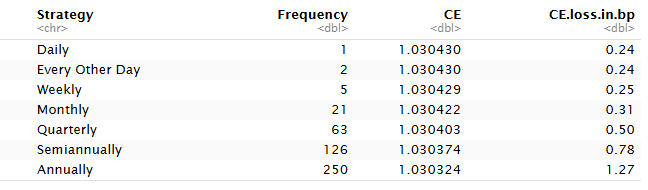

In [ ]:
tabela_simulacao <- function(r, lam, sigma, gamma, T, W0, N, seed, show_progress = TRUE) {
  set.seed(seed)

  # 1. Parâmetros e Solução Analítica (C*) [4-6]
  w_star <- lam / (gamma * sigma) #Fração ótima (Merton)(2.8)
  mu_p <- r + sigma * lam #Retorno esperado do portfólio(2.9)

  # Cálculo analítico da utilidade esperada contínua (E_U_opt) [6] (3.32)
  term1 <- (mu_p - 0.5 * (sigma * w_star)^2) * T * (1 - gamma)
  term2 <- 0.5 * (sigma * w_star)^2 * T * (1 - gamma)^2
  E_U_opt <- (W0^(1 - gamma) / (1 - gamma)) * exp(term1 + term2)

  C_star <- (E_U_opt * (1 - gamma))^(1 / (1 - gamma)) #(3.25)

  # 2. Frequências de Rebalanceamento das Fontes (Tabela 4.1) [3]
  frequencias <- c(
    "Daily"            = 250,
    "Every Other Day"  = 125,
    "Weekly"           = 52,
    "Monthly"          = 12,
    "Quarterly"        = 4,
    "Semiannually"     = 2,
    "Annually"         = 1
  )

  resultados <- data.frame(
    Strategy = names(frequencias),
    C_star = rep(C_star, length(frequencias)),
    C_discrete = NA,
    CE_loss_bps = NA,
    CI_CE_loss_bps = NA
  )

  # 3. Loop de Simulação para cada Estratégia
  for (j in 1:length(frequencias)) {
    if(show_progress) cat(sprintf("Simulando estratégia: %s...\n", names(frequencias)[j]))

    freq <- frequencias[j]
    dt <- T / freq

    #Equação (3.2)
    drift_s <- (r + lam * sigma - 0.5 * sigma^2) * dt
    vol_s <- sigma * sqrt(dt)

    W_disc <- rep(W0, N) #cria um vetor com N cópias do valor inicial W0
    W_cont_sim <- rep(W0, N)

    for (i in 1:freq) {
      Z <- rnorm(N) #(3.4)
      ret_ativo <- exp(drift_s + vol_s * Z) #vetor com N retornos diferentes
      ret_rf <- exp(r * dt) #Retorno do ativo livre de risco

      # Evolução da riqueza com rebalanceamento discreto (Eq. 3.23) [8]
      W_disc <- W_disc * (w_star * ret_ativo + (1 - w_star) * ret_rf)

      # Trajetória contínua simulada para redução de variância (2.9)
      d_cont <- ((r + lam*sigma)*w_star + r*(1-w_star) - 0.5*(sigma*w_star)^2)*dt #Drift contínuo
      v_cont <- sigma * w_star * sqrt(dt) #Volatilidade contínua
      W_cont_sim <- W_cont_sim * exp(d_cont + v_cont * Z)
    }

    # 4. Cálculo da Utilidade e Redução de Variância [9, 10]
    U_disc <- (W_disc^(1 - gamma)) / (1 - gamma) #X
    U_cont_sim <- (W_cont_sim^(1 - gamma)) / (1 - gamma) #Y variavel de controle

    # Ajuste por Variável de Controle [9, 10]
    beta <- cov(U_disc, U_cont_sim) / var(U_cont_sim) #3.29
    U_adj_vec <- U_disc - beta * (U_cont_sim - E_U_opt) #3.27 ou 3.31
    U_adj_mean <- mean(U_adj_vec)

    # --- Cálculo do Intervalo de Confiança (Seção 3.6) [2] ---
    # Erro padrão da utilidade ajustada
    se_U <- sd(U_adj_vec) / sqrt(N) #3.36
    # Limites de 95% para a utilidade
    U_lower <- U_adj_mean - 1.96 * se_U
    U_upper <- U_adj_mean + 1.96 * se_U

    # 5. Conversão para Certeza Equivalente e Perda [2, 5]
    C_disc <- (U_adj_mean * (1 - gamma))^(1 / (1 - gamma)) #3.25

    # Mapeamento dos limites de utilidade para limites de CE
    C_lower_bound <- (U_lower * (1 - gamma))^(1 / (1 - gamma))
    C_upper_bound <- (U_upper * (1 - gamma))^(1 / (1 - gamma))

    # Cálculo das perdas em bps (Nota: Utilidade menor -> CE menor -> Perda maior) [2]
    loss_main <- ((C_star - C_disc) / C_star) * 10000
    loss_from_upper_U <- ((C_star - C_upper_bound) / C_star) * 10000
    loss_from_lower_U <- ((C_star - C_lower_bound) / C_star) * 10000

    resultados$C_discrete[j] <- C_disc
    resultados$CE_loss_bps[j] <- loss_main
    resultados$CI_CE_loss_bps[j] <- sprintf("( %.4f; %.4f )", loss_from_upper_U, loss_from_lower_U)
  }

  return(resultados)
}

# --- Execução ---
start_time <- Sys.time()

df1 <- tabela_simulacao(
  r = 0.02,
  lam = 0.2,
  sigma = 0.25,
  gamma = 2,
  T = 1,
  W0 = 1,
  N = 10000000,
  seed = 123,
  show_progress = TRUE
)

end_time <- Sys.time()

print(df1)
cat(sprintf("\nTempo total: %.2f minutos\n",
            difftime(end_time, start_time, units = "mins")))

Estou simulando o GBM diretamente no passo de rebalanceamento (Δt). Faz alguma diferença, teórica ou numérica, simular primeiro uma malha mais fina (tipo diária) e depois aplicar as estratégias, ou isso é equivalente no caso do GBM?


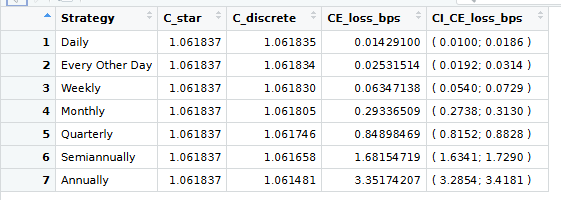

In [ ]:
start_time <- Sys.time()

df2 <- tabela_simulacao(
  r = 0.02,
  lam = 0.2,
  sigma = 0.25,
  gamma = 2,
  T = 1,
  W0 = 1,
  N = 35000000,
  seed = 123,
  show_progress = TRUE
)

end_time <- Sys.time()

print(df1)
cat(sprintf("\nTempo total: %.2f minutos\n",
            difftime(end_time, start_time, units = "mins")))

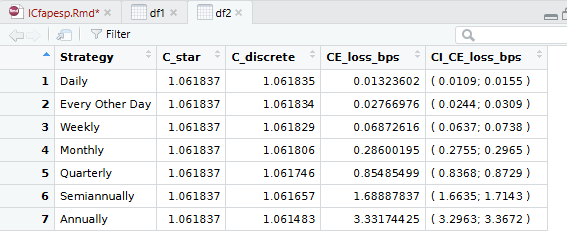

In [ ]:
tabela_simulacao_nova <- function(r, lam, sigma, gamma, T, W0, N, seed, show_progress = TRUE) {
  set.seed(seed)

  # 1. Parâmetros e Solução Analítica (C*) [4-6]
  w_star <- lam / (gamma * sigma)
  #mu_p <- r + sigma * lam

  # Cálculo analítico da utilidade esperada contínua (E_U_opt) [6]
  #term1 <- (mu_p - 0.5 * (sigma * w_star)^2) * T * (1 - gamma)

  # O drift correto é r + w_star * lam * sigma (drift do portfólio)
  mu_wealth <- r + w_star * lam * sigma
  term1 <- (mu_wealth - 0.5 * (sigma * w_star)^2) * T * (1 - gamma)
  term2 <- 0.5 * (sigma * w_star)^2 * T * (1 - gamma)^2
  E_U_opt <- (W0^(1 - gamma) / (1 - gamma)) * exp(term1 + term2)
  C_star <- (E_U_opt * (1 - gamma))^(1 / (1 - gamma))

  # 2. Frequências de Rebalanceamento das Fontes (Tabela 4.1) [3]
  frequencias <- c(
    "Daily"            = 250,
    "Every Other Day"  = 125,
    "Weekly"           = 52,
    "Monthly"          = 12,
    "Quarterly"        = 4,
    "Semiannually"     = 2,
    "Annually"         = 1
  )

  resultados <- data.frame(
    Strategy = names(frequencias),
    C_star = rep(C_star, length(frequencias)),
    C_discrete = NA,
    CE_loss_bps = NA,
    CI_CE_loss_bps = NA  # Nova coluna para o Intervalo de Confiança [3]
  )

  # 3. Loop de Simulação para cada Estratégia [7, 8]
  for (j in 1:length(frequencias)) {
    if(show_progress) cat(sprintf("Simulando estratégia: %s...\n", names(frequencias)[j]))

    freq <- frequencias[j]
    dt <- T / freq

    drift_s <- (r + lam * sigma - 0.5 * sigma^2) * dt
    vol_s <- sigma * sqrt(dt)

    W_disc <- rep(W0, N)
    W_cont_sim <- rep(W0, N)

    for (i in 1:freq) {
      Z <- rnorm(N)
      ret_ativo <- exp(drift_s + vol_s * Z)
      ret_rf <- exp(r * dt)

      # Evolução da riqueza com rebalanceamento discreto (Eq. 3.23) [8]
      W_disc <- W_disc * (w_star * ret_ativo + (1 - w_star) * ret_rf)

      # Trajetória contínua simulada para redução de variância [6, 9]
      d_cont <- ((r + lam*sigma)*w_star + r*(1-w_star) - 0.5*(sigma*w_star)^2)*dt
      v_cont <- sigma * w_star * sqrt(dt)
      W_cont_sim <- W_cont_sim * exp(d_cont + v_cont * Z)
    }

    # 4. Cálculo da Utilidade e Redução de Variância [9, 10]
    U_disc <- (W_disc^(1 - gamma)) / (1 - gamma)
    U_cont_sim <- (W_cont_sim^(1 - gamma)) / (1 - gamma)

    # Ajuste por Variável de Controle [9, 10]
    beta <- cov(U_disc, U_cont_sim) / var(U_cont_sim)
    U_adj_vec <- U_disc - beta * (U_cont_sim - E_U_opt)
    U_adj_mean <- mean(U_adj_vec)

    # --- Cálculo do Intervalo de Confiança (Seção 3.6) [2] ---
    # Erro padrão da utilidade ajustada
    se_U <- sd(U_adj_vec) / sqrt(N)
    # Limites de 95% para a utilidade
    U_lower <- U_adj_mean - 1.96 * se_U
    U_upper <- U_adj_mean + 1.96 * se_U

    # 5. Conversão para Certeza Equivalente e Perda [2, 5]
    C_disc <- (U_adj_mean * (1 - gamma))^(1 / (1 - gamma))

    # Mapeamento dos limites de utilidade para limites de CE
    C_lower_bound <- (U_lower * (1 - gamma))^(1 / (1 - gamma))
    C_upper_bound <- (U_upper * (1 - gamma))^(1 / (1 - gamma))

    # Cálculo das perdas em bps (Nota: Utilidade menor -> CE menor -> Perda maior) [2]
    loss_main <- ((C_star - C_disc) / C_star) * 10000
    loss_from_upper_U <- ((C_star - C_upper_bound) / C_star) * 10000
    loss_from_lower_U <- ((C_star - C_lower_bound) / C_star) * 10000

    resultados$C_discrete[j] <- C_disc
    resultados$CE_loss_bps[j] <- loss_main
    resultados$CI_CE_loss_bps[j] <- sprintf("( %.4f; %.4f )", loss_from_upper_U, loss_from_lower_U)
  }

  return(resultados)
}

start_time <- Sys.time()

df3 <- tabela_simulacao_nova(
  r = 0.02,
  lam = 0.2,
  sigma = 0.25,
  gamma = 2,
  T = 1,
  W0 = 1,
  N = 35000000,
  seed = 123,
  show_progress = TRUE
)

end_time <- Sys.time()

print(df3)
cat(sprintf("\nTempo total: %.2f minutos\n",
            difftime(end_time, start_time, units = "mins")))

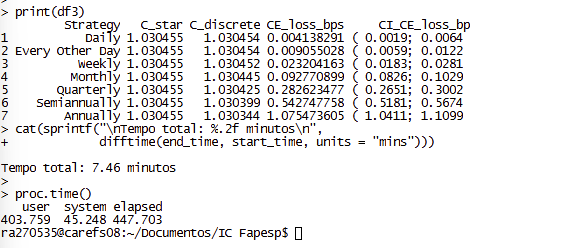